# Exercise 1

In [5]:
import pandas as pd  # For handling data in DataFrame
from selenium import webdriver  # For controlling the web browser and interacting with HTML content
from selenium.webdriver.chrome.service import Service  # For setting up ChromeDriver as a service
from selenium.webdriver.common.by import By  # To locate HTML elements by XPath
import time  # For handling wait times
import random  # For randomizing scroll and wait times

# Optional set up step. They can use any book category with 2+ pages.

In [6]:
# Set up ChromeDriver using webdriver_manager
chrome_options = Options()  # Initialize Chrome options (optional)
service = Service(ChromeDriverManager().install())  # Install and set up ChromeDriver as a service

# Create a ChromeDriver instance
browser = webdriver.Chrome(service=service)

# Open the website
url = 'https://books.toscrape.com/catalogue/category/books/historical-fiction_4/index.html'
browser.get(url)

# Maximize the browser window for better visibility
browser.maximize_window()

# Wait a random time between 3-7 seconds before starting
time.sleep(random.uniform(3, 7))

In [7]:
# Function to scroll down the page randomly
def random_scroll(browser, total_wait_time=5):
    # Get the total height of the page
    total_height = browser.execute_script("return document.body.scrollHeight")
    
    # Number of steps to scroll (adjust this number for finer control)
    scroll_steps = random.randint(3, 7)
    
    # Height to scroll per step
    scroll_increment = total_height // scroll_steps
    
    # Time to wait per step
    time_per_step = total_wait_time / scroll_steps
    
    # Scroll in steps
    for step in range(scroll_steps):
        # Scroll down
        browser.execute_script(f"window.scrollBy(0, {scroll_increment});")
        # Wait for a random time between each scroll
        time.sleep(random.uniform(0.5 * time_per_step, 1.5 * time_per_step))
    
    # Ensure we scroll to the bottom of the page
    browser.execute_script("window.scrollTo(0, document.body.scrollHeight);")


In [8]:
# Scrape data from the current page
def scrape_books(browser):
    # Initialize lists to store the book data
    titles = []
    star_ratings = []
    urls = []
    prices = []
    availabilities = []
    
    # Locate all book elements on the page
    books = browser.find_elements(By.XPATH, "//article[@class='product_pod']")
    
    for book in books:
        # Extract the title
        title_element = book.find_element(By.XPATH, ".//h3/a")
        title = title_element.get_attribute('title')
        titles.append(title)
        
        # Extract the star rating class (e.g., star-rating Three)
        star_rating_element = book.find_element(By.XPATH, ".//p[contains(@class, 'star-rating')]")
        star_rating = star_rating_element.get_attribute('class').split()[-1]  # Get the last class which is the rating
        star_ratings.append(star_rating)
        
        # Extract the URL for the book's detail page
        url = title_element.get_attribute('href')
        urls.append(url)
        
        # Extract the price
        price = book.find_element(By.XPATH, ".//div[@class='product_price']/p[@class='price_color']").text
        prices.append(price)
        
        # Extract availability
        availability = book.find_element(By.XPATH, ".//div[@class='product_price']/p[@class='instock availability']").text.strip()
        availabilities.append(availability)
    
    return titles, star_ratings, urls, prices, availabilities


In [9]:
url = "https://books.toscrape.com/catalogue/category/books/childrens_11/index.html"
browser = webdriver.Chrome()
browser.get(url)

In [6]:
titles, star_ratings, urls, prices, availabilities = scrape_books(browser)

# Go to next page

In [10]:
next_button = browser.find_element(By.CLASS_NAME, "next")
print(next_button)
link = next_button.find_element(By.XPATH, "./a")
link.click()

<selenium.webdriver.remote.webelement.WebElement (session="c7db06fe49d661db848004a03cd336b2", element="f.B418C89638904B3811C044F8EE7C1F2C.d.0B09BE3AFD20CF174D8384731CC155E1.e.958")>


In [11]:
url = "https://books.toscrape.com/catalogue/category/books/childrens_11/index.html"
browser = webdriver.Chrome()
browser.get(url)
title = []
stars = []
url = []
price = []
avail = []
while True:
    titles, star_ratings, urls, prices, availabilities = scrape_books(browser)
    title.extend(titles)
    stars.extend(star_ratings)
    price.extend(prices)
    try:
        next_button = browser.find_element(By.CLASS_NAME, "next")
        print(next_button)
        link = next_button.find_element(By.XPATH, "./a")
        link.click()
    except:
        print("There's no next button")
        break

display(title)

<selenium.webdriver.remote.webelement.WebElement (session="3cd5fe0604b67c320ae2bafa884e49ba", element="f.AA051F01AF72A02DEC178AD2188000A0.d.BBADC5DA683A02F5FC40F6B33512CBAE.e.958")>
There's no next button


['Birdsong: A Story in Pictures',
 'The Bear and the Piano',
 'The Secret of Dreadwillow Carse',
 'The White Cat and the Monk: A Retelling of the Poem “Pangur Bán”',
 'Little Red',
 "Walt Disney's Alice in Wonderland",
 'Twenty Yawns',
 'Rain Fish',
 'Once Was a Time',
 'Luis Paints the World',
 'Nap-a-Roo',
 'The Whale',
 'Shrunken Treasures: Literary Classics, Short, Sweet, and Silly',
 'Raymie Nightingale',
 'Playing from the Heart',
 'Maybe Something Beautiful: How Art Transformed a Neighborhood',
 'The Wild Robot',
 'The Thing About Jellyfish',
 'The Lonely Ones',
 'The Day the Crayons Came Home (Crayons)',
 'The Cat in the Hat (Beginner Books B-1)',
 'Red: The True Story of Red Riding Hood',
 'Horrible Bear!',
 'Green Eggs and Ham (Beginner Books B-16)',
 'Counting Thyme',
 'Are We There Yet?',
 'Diary of a Minecraft Zombie Book 1: A Scare of a Dare (An Unofficial Minecraft Book)',
 'Matilda',
 'Charlie and the Chocolate Factory (Charlie Bucket #1)']

In [13]:
my_dict = {'title': title, 'stars': stars, 'price': price}
df_books = pd.DataFrame(my_dict)
display(df_books)

,title,stars,price
0,Birdsong: A Story in Pictures,Three,£54.64
1,The Bear and the Piano,One,£36.89
2,The Secret of Dreadwillow Carse,One,£56.13
3,The White Cat and the Monk: A Retelling of the...,Four,£58.08
4,Little Red,Three,£13.47
5,Walt Disney's Alice in Wonderland,Five,£12.96
6,Twenty Yawns,Two,£22.08
7,Rain Fish,Three,£23.57
8,Once Was a Time,Two,£18.28
9,Luis Paints the World,Three,£53.95


# Exercise 2

In [12]:
#pip install yfinance (optional if they haven't installed)

In [14]:
import yfinance as yf

In [16]:
ticker_symbol = "^IXIC"
stock1_data = yf.download(ticker_symbol, period="2mo")

# display all data available
#display(stock1_data)

[*********************100%***********************]  1 of 1 completed


In [17]:
ticker_symbol = "^GSPC"
stock2_data = yf.download(ticker_symbol, period="2mo")

# display all data available
#display(stock2_data)

[*********************100%***********************]  1 of 1 completed


In [18]:
ticker_symbol = "^DJI"
stock3_data = yf.download(ticker_symbol, period="2mo")

# display all data available
#display(stock2_data)

[*********************100%***********************]  1 of 1 completed


# Other indices - S&P = ^GSPC   Dow = ^DJI

In [19]:
# extract the closing prices
closing_prices_df = stock1_data[['Close']]
closing_prices_df2 = stock2_data[['Close']]
closing_prices_df3 = stock3_data[['Close']]
#display(closing_prices_df)

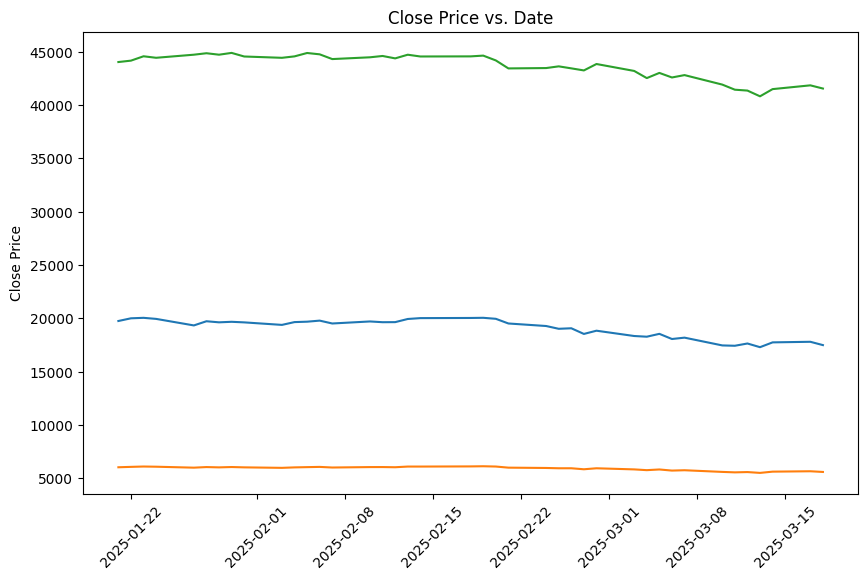

In [20]:
import matplotlib.pyplot as plt

# Assuming 'closing_prices_df' has 'Date' as the index and 'Price' as a column

# Plotting the 'Price' column against the 'Date' index
plt.figure(figsize=(10, 6))
plt.plot(closing_prices_df.index, stock1_data['Close'], label='Nasdaq')
plt.plot(closing_prices_df2.index, stock2_data['Close'], label='S&P')
plt.plot(closing_prices_df3.index, stock3_data['Close'], label='Dow Jones')

# Adding labels and title
plt.ylabel('Close Price')
plt.title('Close Price vs. Date')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability


# Show the plot
plt.show()
